In [1]:
# Link dos DATASETS

dados_f1 = 'https://raw.githubusercontent.com/Mirlaa/s-ries-temporais-statsmodels/main/Dados/Temperatura_mensal_F1.csv'
dados_f2 = 'https://raw.githubusercontent.com/Mirlaa/s-ries-temporais-statsmodels/main/Dados/Temperatura_mensal_F2.csv'
dados_f3 = 'https://raw.githubusercontent.com/Mirlaa/s-ries-temporais-statsmodels/main/Dados/Temperatura_mensal_F3.csv'

In [2]:
# Importando bibliotecas

import pandas as pd
import matplotlib.pyplot as plt

# Fazenda 1

![Alt text: Imagem de uma fazenda com plantações de uvas](https://github.com/Mirlaa/s-ries-temporais-statsmodels/blob/main/imagens/Fazenda%201.png?raw=true)

### PART 1

In [3]:
# Mostrando os dados da Fazenda 1

df_f1 = pd.read_csv(dados_f1)
df_f1

,DATA,TEMP
0,1963-05-01,23.11
1,1963-06-01,24.20
2,1963-07-01,25.37
3,1963-08-01,23.86
4,1963-09-01,23.03
...,...,...
727,2023-12-01,19.49
728,2024-01-01,19.28
729,2024-02-01,19.73
730,2024-03-01,20.44


In [4]:
# Mudando o tipo de dado da coluna DATA para datetime e definindo como index

df_f1['DATA'] = pd.to_datetime(df_f1['DATA'], format = '%Y-%m-%d' )
df_f1.set_index('DATA', inplace=True)
df_f1

,TEMP
DATA,
1963-05-01,23.11
1963-06-01,24.20
1963-07-01,25.37
1963-08-01,23.86
1963-09-01,23.03
...,...
2023-12-01,19.49
2024-01-01,19.28
2024-02-01,19.73


<Axes: xlabel='DATA'>

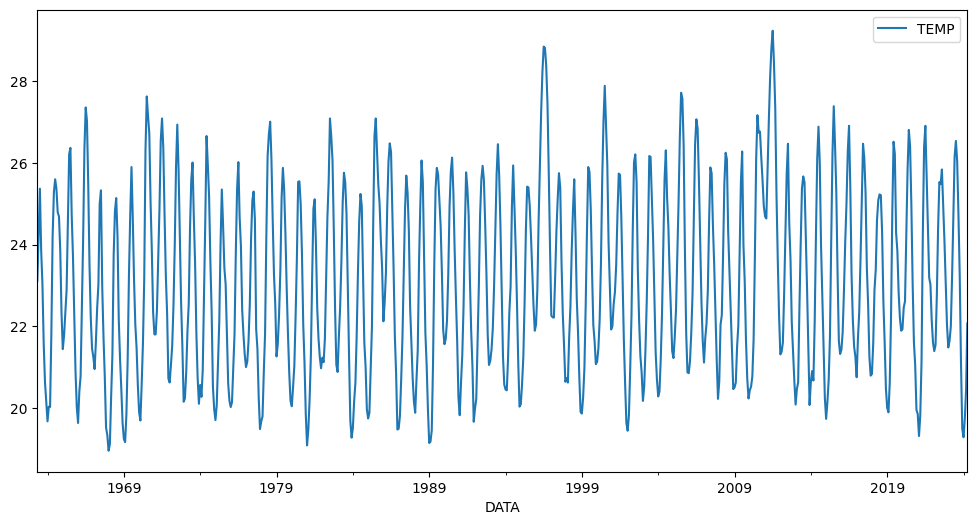

In [5]:
# Plotando gráfico de DATA x Temperatura 

df_f1.plot(figsize=(12,6))

## Modelo ingênuo

Um modelo ingênuo (naive) em séries temporais é um dos métodos de previsão mais simples, baseando-se na suposição de que o melhor preditor para qualquer ponto futuro é o valor mais recente disponível na série. Isso significa que a previsão para todos os pontos futuros será igual ao último valor observado.

In [6]:
# Deslocando os dados de temperatura para uma linha a frente

df_f1.shift()

,TEMP
DATA,
1963-05-01,NaN
1963-06-01,23.11
1963-07-01,24.20
1963-08-01,25.37
1963-09-01,23.86
...,...
2023-12-01,21.11
2024-01-01,19.49
2024-02-01,19.28


## Avaliando a estacionariedade

In [7]:
# Medindo a estacionariedade dos dados, utilizando duas métricas: adfuller and kpss

from statsmodels.tsa.stattools import adfuller, kpss

def estac(df):

    adf = adfuller(df)

    print(f'Valor-p do Teste ADF: {adf[1]:.4f}')

    if adf[1] > 0.05:
        print('Não rejeitar a Hipótesqe Nula: a série não é estacionária\n')
    else:
        print('Rejeitar a Hipótese Nula: a série é estacionária\n')



    kpss_saida = kpss(df)

    print(f'Valor-p do Teste KPSS: {kpss_saida[1]:.4f}')

    if kpss_saida[1] > 0.05:
        print('Não rejeitar a Hipótesqe Nula: a série é estacionária\n')
    else:
        print('Rejeitar a Hipótese Nula: a série não é estacionária\n')


In [8]:
estac(df_f1)

Valor-p do Teste ADF: 0.0000
Rejeitar a Hipótese Nula: a série é estacionária

Valor-p do Teste KPSS: 0.0798
Não rejeitar a Hipótesqe Nula: a série é estacionária



Uma série estacionária é aquela que não muda com o tempo, sua média, variância e autocorrelação entre pontos se mantém a mesma com o passar do tempo

### PART 2

In [9]:
# Para aplicar modelos que não possuem a possibilidade de separação, vamos fazer manualmente, separando o dataset, em treino e teste

divisao = int(len(df_f1)*0.7)

treino = df_f1.iloc[:divisao].asfreq('MS')   # We use asfreq to guarantee that every month will be in the dataset, even though there is no data associated to that month, making a continuous dataset for months

teste = df_f1.iloc[divisao:].asfreq('MS')

## Modelo Autoregressivo (AR)

Um modelo Autorregressivo (AR) é um tipo de modelo de previsão para séries temporais que utiliza uma combinação linear de valores passados da própria série para fazer previsões futuras. Ele se baseia na ideia de que observações passadas podem ser usadas para prever observações futuras de maneira estatisticamente significativa, especialmente quando a série exibe correlação ao longo do tempo.

A equação básica de um modelo autorregressivo de ordem $(p)$ (lag de $p$ períodos) é dada por:

$X_t = c + \beta_1 X_{t-1} + \beta_2 X_{t-2} + \dots + \beta_p X_{t-p} + \epsilon_t$

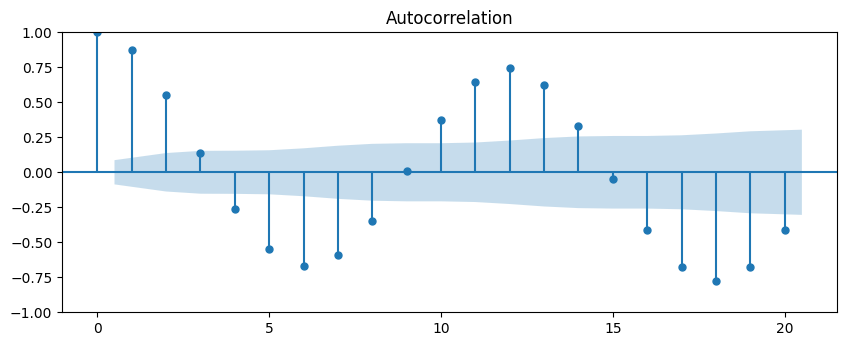

In [10]:
# Importando biblioteca para plotar acf e pacf

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plotting the acf values

fig = plt.figure(figsize=(10,8))

ax1 = fig.add_subplot(211)

fig = plot_acf(treino, lags = 20, ax=ax1) 

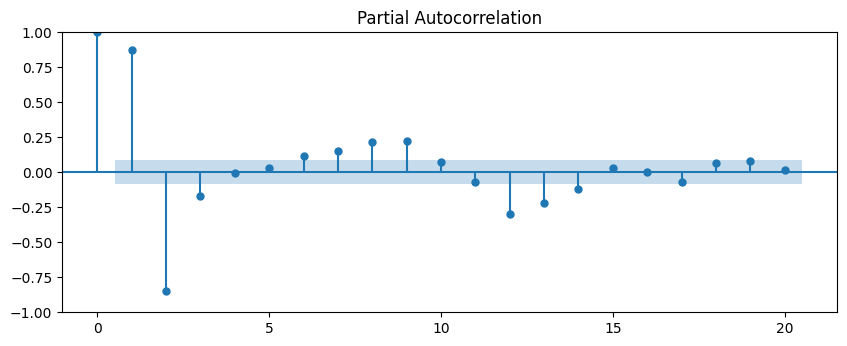

In [11]:
# Plotando gráfico de pacf, retorna a normalidade após lag=14

fig = plt.figure(figsize=(10,8))

ax1 = fig.add_subplot(212)

fig = plot_pacf(treino, lags = 20, ax=ax1)



In [12]:
# Decidido qual será o valor de p=14


# Importando autoreg
from statsmodels.tsa.ar_model import AutoReg

# Definindo o modelo
ar_mod = AutoReg(treino, 14, old_names=False)

ar_res = ar_mod.fit()


# Imprimindo sumário
print(ar_res.summary())






# old_names=True: Uses more traditional names e shorter ones like (ex.: x1, x2, etc.).

                            AutoReg Model Results                             
Dep. Variable:                   TEMP   No. Observations:                  512
Model:                    AutoReg(14)   Log Likelihood                -317.490
Method:               Conditional MLE   S.D. of innovations              0.458
Date:                Sun, 20 Jul 2025   AIC                            666.981
Time:                        11:54:47   BIC                            734.350
Sample:                    07-01-1964   HQIC                           693.421
                         - 12-01-2005                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0973      0.649      7.855      0.000       3.825       6.369
TEMP.L1        1.1971      0.044     27.078      0.000       1.110       1.284
TEMP.L2       -0.3092      0.069     -4.470      0.0

c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\ar_model.py:1138: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ar_params[lag] = -params[i]


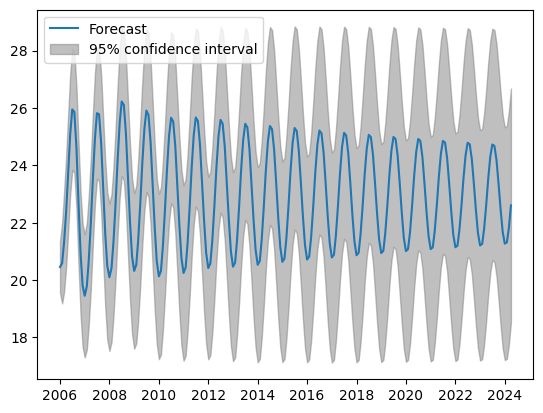

In [13]:
# Conferindo os resultado so sumário em um gráfico

# Importando a biblioteca AutoRegResults
from statsmodels.tsa.ar_model import AutoRegResults

# Creando o modelo
mod_result = AutoRegResults(ar_mod, ar_res.params, ar_res.cov_params)

# Plotando um gráfico, com área de confiança
fig = mod_result.plot_predict(len(treino), len(treino)+len(teste)-1)




# We can see that our graph tend to get shorter as time goes, that indicates that with time our forecast become less precise, and have this tendency

Link: https://cursos.alura.com.br/course/regressao-realizando-previsao-series-temporais-statsmodels/task/165214

In [14]:
# Agora vamos usar métricas, para avaliar nosso redsultado

# Importando biblioteca para as métricas de erros
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Creating a function to return a graph with our forecast and the data, and write our metrics 
def plot_prev(treino, teste, mod, nome_mod = ''):

  previsoes = mod.predict(len(treino), len(treino) + len(teste)-1, dynamic=False)

  plt.figure(figsize=(12, 5))

  plt.plot(teste.index, teste, label='Esperado')
  plt.plot(previsoes.index, previsoes, label='Previsto', color='red')

  plt.title(f'Previsão modelo {nome_mod}')
  plt.ylabel('Temperatura')
  plt.legend()
  plt.show()

  print('\nMétricas:\n')
  mae = mean_absolute_error(teste, previsoes)
  print(f'MAE: {mae}')

  mse = mean_squared_error(teste, previsoes)
  print(f'MSE: {mse}')

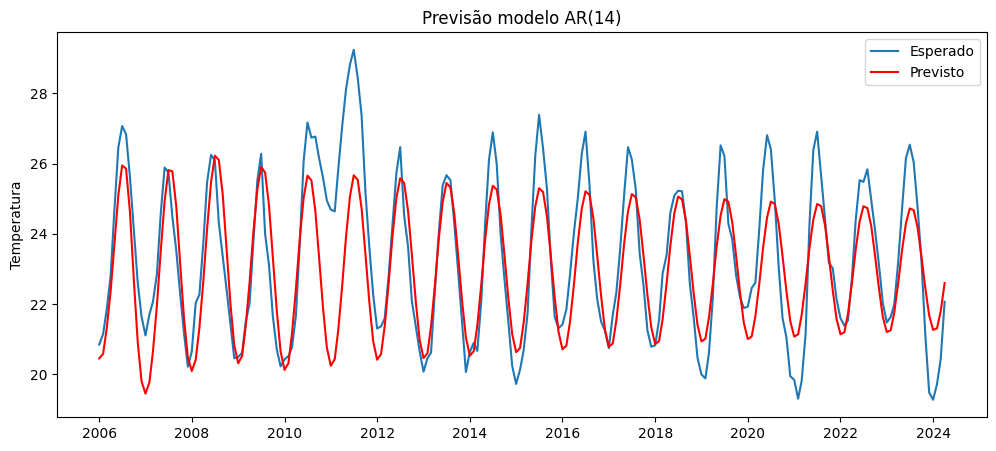


Métricas:

MAE: 1.0427063983973868
MSE: 1.8489038142171543


In [15]:
plot_prev(treino, teste, ar_res, 'AR(14)')

Link Passo a Passo: https://cursos.alura.com.br/course/regressao-realizando-previsao-series-temporais-statsmodels/task/165224

### Busca de parâmetros

In [16]:
# Importando biblioteca para busca do melhor parâmetro p
from statsmodels.tsa.ar_model import ar_select_order


# Primeiro, escolhemos p, usando o gráfico pacf, e checando em que lag o gráfico volta a área de confiabilidade, para depois utilizar esta estratégia
ar_selecao = ar_select_order(treino, 35, old_names=False, ic='aic')

In [17]:
ar_selecao.ar_lags # lag escolhido foi 34

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34]

In [18]:
# Com o novo modelo, vamos plotar o sumário

ar_sel_res = ar_selecao.model.fit()

ar_sel_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                   TEMP   No. Observations:                  512
Model:                    AutoReg(34)   Log Likelihood                -265.842
Method:               Conditional MLE   S.D. of innovations              0.422
Date:                Sun, 20 Jul 2025   AIC                            603.684
Time:                        11:54:48   BIC                            753.790
Sample:                    03-01-1966   HQIC                           662.698
                         - 12-01-2005                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4648      1.091      4.092      0.000       2.326       6.603
TEMP.L1        1.1355      0.045     25.067      0.000       1.047       1.224
TEMP.L2       -0.2017      0.068     -2.958      0.003      -0.335      -0.068
TEMP.L3       -0.0559      0.069     -0.813      0.416      -0.191       0.079
TEMP.L4       -0.0181      0.069     -0.262      0.793      -0.154       0.117
TEMP.L5       -0.0066      0.069     -0.096      0.924      -0.142       0.129
TEMP.L6        0.1069      0.069      1.549      0.121      -0.028       0.242
TEMP.L7       -0.1038      0.069     -1.507      0.132      -0.239       0.031
TEMP.L8       -0.0777      0.069     -1.131      0.258      -0.212       0.057
TEMP.L9        0.0274      0.068      0.401      0.689      -0.107       0.161
TEMP.L10      -0.0058      0.068     -0.085      0.932      -0.140       0.128
TEMP.L11       0.2272      0.068      3.334      0.001       0.094       0.361
TEMP.L12      -0.0636      0.069     -0.924      0.355      -0.198       0.071
TEMP.L13      -0.0550      0.069     -0.799      0.424      -0.190       0.080
TEMP.L14      -0.1661      0.069     -2.416      0.016      -0.301      -0.031
TEMP.L15       0.0480      0.069      0.694      0.488      -0.088       0.183
TEMP.L16       0.1210      0.069      1.750      0.080      -0.015       0.256
TEMP.L17      -0.0721      0.069     -1.039      0.299      -0.208       0.064
TEMP.L18      -0.1056      0.070     -1.518      0.129      -0.242       0.031
TEMP.L19       0.0112      0.069      0.161      0.872      -0.125       0.147
TEMP.L20       0.0852      0.069      1.227      0.220      -0.051       0.221
TEMP.L21       0.0048      0.069      0.069      0.945      -0.131       0.140
TEMP.L22      -0.0354      0.069     -0.515      0.606      -0.170       0.099
TEMP.L23       0.0781      0.069      1.138      0.255      -0.056       0.212
TEMP.L24       0.0545      0.068      0.805      0.421      -0.078       0.187
TEMP.L25       0.0167      0.068      0.247      0.805      -0.116       0.149
TEMP.L26      -0.1874      0.068     -2.775      0.006      -0.320      -0.055
TEMP.L27       0.0680      0.068      1.003      0.316      -0.065       0.201
TEMP.L28      -0.0808      0.068     -1.192      0.233      -0.214       0.052
TEMP.L29      -0.0424      0.068     -0.625      0.532      -0.175       0.091
TEMP.L30       0.0990      0.068      1.462      0.144      -0.034       0.232
TEMP.L31      -0.0006      0.068     -0.008      0.993      -0.133       0.132
TEMP.L32       0.0809      0.067      1.207      0.228      -0.051       0.212
TEMP.L33      -0.2042      0.066     -3.092      0.002      -0.334      -0.075
TEMP.L34       0.1240      0.044      2.802      0.005       0.037       0.211
                                    Roots                                     
==============================================================================
                   Real          Imaginary           Modulus         Frequency
--

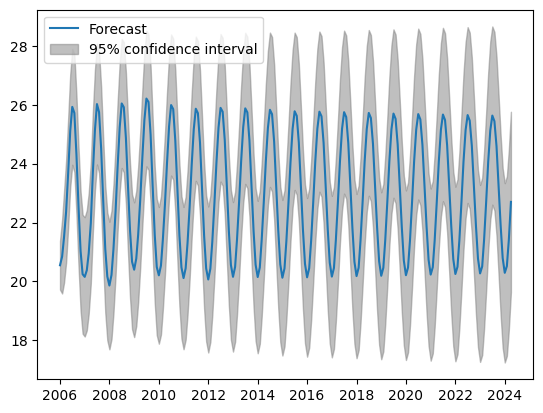

In [19]:
# Plotando um gráfico com a nossa previsão e área de confiança

fig = ar_sel_res.plot_predict(len(treino), len(treino) + len(teste)-1)

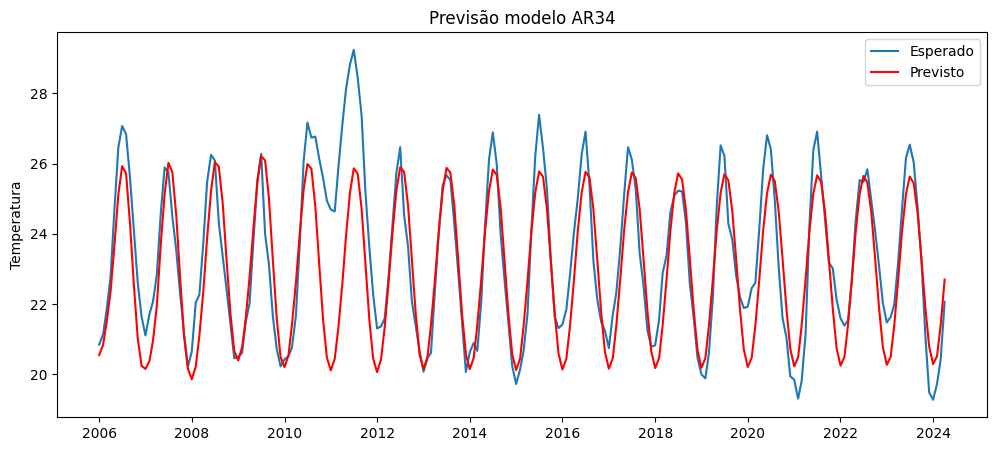


Métricas:

MAE: 0.9474776896250366
MSE: 1.6610673113369703


In [20]:
# Plotando gráfico com as previsões e os dados de teste juntos de modo a conseguir avaliar a precisão das respostas, depois avaliando MAE e MSE

plot_prev(treino, teste, ar_sel_res, 'AR34')

**AIC, BIC, HQIC:** https://cursos.alura.com.br/course/regressao-realizando-previsao-series-temporais-statsmodels/task/165227

https://cursos.alura.com.br/course/regressao-realizando-previsao-series-temporais-statsmodels/task/165229

# Fazenda 2

![Alt text: Imagem de uma fazenda com plantações de tomates](https://github.com/Mirlaa/s-ries-temporais-statsmodels/blob/main/imagens/Fazenda%202.png?raw=true)

In [21]:
# Carregando os dados da Fazenda 2

df_f2 = pd.read_csv(dados_f2)

df_f2

,DATA,TEMP
0,1966-02-01,23.436171
1,1966-03-01,29.787675
2,1966-04-01,25.626345
3,1966-05-01,22.958315
4,1966-06-01,19.513770
...,...,...
694,2023-12-01,15.033869
695,2024-01-01,17.323596
696,2024-02-01,22.818941
697,2024-03-01,29.429283


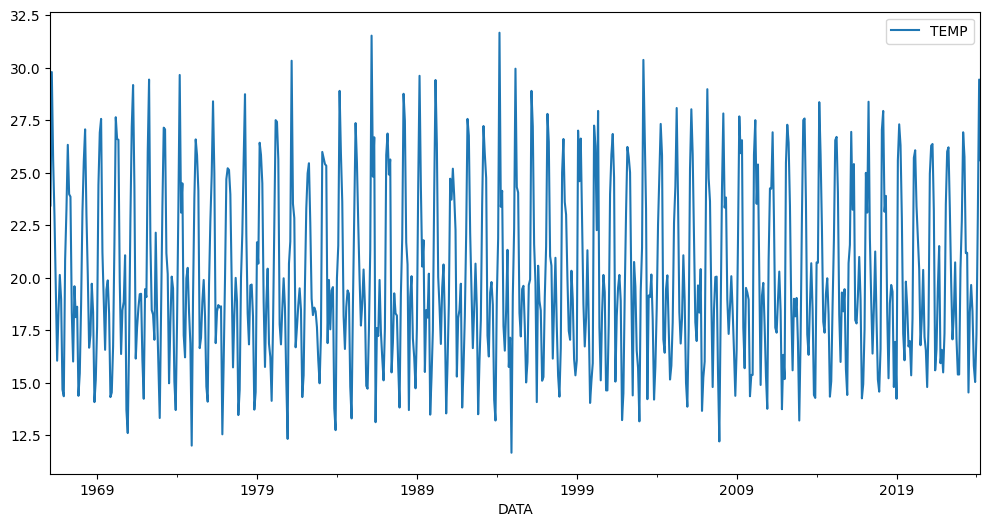

In [22]:
# Convertendo a coluna DATA para datetime e transformando-a em index

df_f2['DATA'] = pd.to_datetime(df_f2['DATA'], format='%Y-%m-%d')

df_f2.set_index(['DATA'], inplace=True, drop=True)

fig = df_f2.plot(figsize=(12, 6))

In [23]:
# Testando a estacionariedade dos dados

estac(df_f2)

Valor-p do Teste ADF: 0.0000
Rejeitar a Hipótese Nula: a série é estacionária

Valor-p do Teste KPSS: 0.1000
Não rejeitar a Hipótesqe Nula: a série é estacionária



C:\Users\mau_a\AppData\Local\Temp\ipykernel_4428\1290556167.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_saida = kpss(df)


In [24]:
# Dividindo em treino e teste

divisao = int(len(df_f2)*0.8)

treino = df_f2.iloc[:divisao].asfreq('MS') # Garantindo que os dados apresentem todos os períodos

teste = df_f2.iloc[divisao:].asfreq('MS')

## Construindo um modelo previsivo

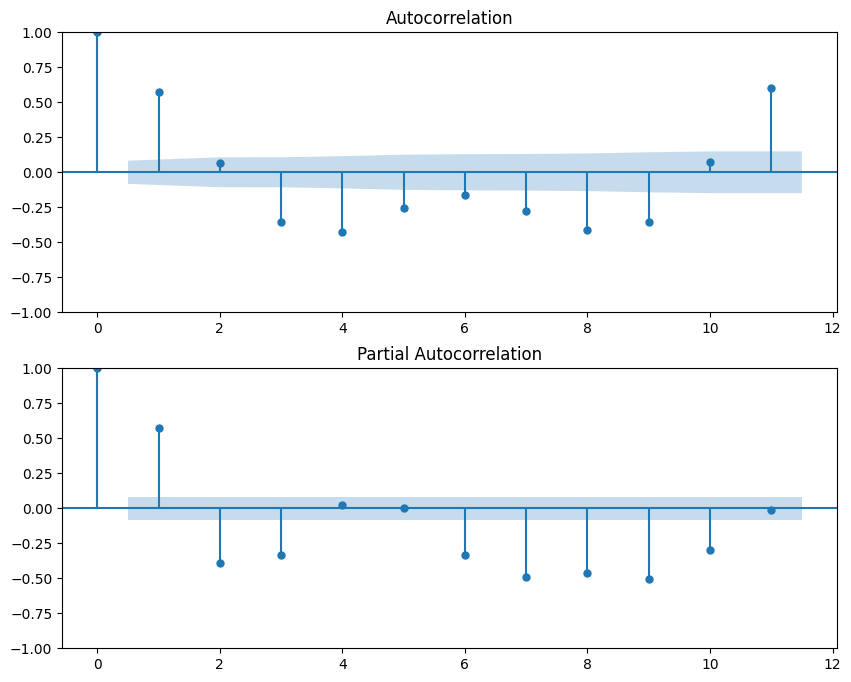

In [25]:
# Plotando gráfico de acf e pacf, para definir valores de p

fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(211)
fig = plot_acf(treino, lags=11, ax=ax1)
ax2 = fig.add_subplot(212)
fig = plot_pacf(treino, lags=11, ax=ax2)

In [26]:
# Sumário para o modelo com lags 10

ar_mod_f2 = AutoReg(treino, lags=10, old_names=False).fit()

ar_mod_f2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                   TEMP   No. Observations:                  559
Model:                    AutoReg(10)   Log Likelihood                -993.284
Method:               Conditional MLE   S.D. of innovations              1.477
Date:                Sun, 20 Jul 2025   AIC                           2010.569
Time:                        11:54:49   BIC                           2062.266
Sample:                    12-01-1966   HQIC                          2030.773
                         - 08-01-2012                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        111.9748      3.244     34.518      0.000     105.617     118.333
TEMP.L1       -0.3349      0.037     -9.170      0.000      -0.406      -0.263
TEMP.L2       -0.3242      0.030    -10.926      0.000      -0.382      -0.266
TEMP.L3       -0.5296      0.027    -19.310      0.000      -0.583      -0.476
TEMP.L4       -0.5385      0.030    -18.176      0.000      -0.597      -0.480
TEMP.L5       -0.4332      0.032    -13.449      0.000      -0.496      -0.370
TEMP.L6       -0.4472      0.032    -13.908      0.000      -0.510      -0.384
TEMP.L7       -0.4639      0.030    -15.660      0.000      -0.522      -0.406
TEMP.L8       -0.4176      0.028    -15.115      0.000      -0.472      -0.363
TEMP.L9       -0.5989      0.030    -20.187      0.000      -0.657      -0.541
TEMP.L10      -0.5185      0.037    -14.177      0.000      -0.590      -0.447
                                    Roots                                     
==============================================================================
                   Real          Imaginary           Modulus         Frequency
------------------------------------------------------------------------------
AR.1             0.8674           -0.5012j            1.0018           -0.0834
AR.2             0.8674           +0.5012j            1.0018            0.0834
AR.3             0.4991           -0.8735j            1.0061           -0.1674
AR.4             0.4991           +0.8735j            1.0061            0.1674
AR.5            -0.0891           -1.0818j            1.0855           -0.2631
AR.6            -0.0891           +1.0818j            1.0855            0.2631
AR.7            -0.7420           -0.8129j            1.1007           -0.3677
AR.8            -0.7420           +0.8129j            1.1007            0.3677
AR.9            -1.1129           -0.3026j            1.1533           -0.4577
AR.10           -1.1129           +0.3026j            1.1533            0.4577
------------------------------------------------------------------------------
"""

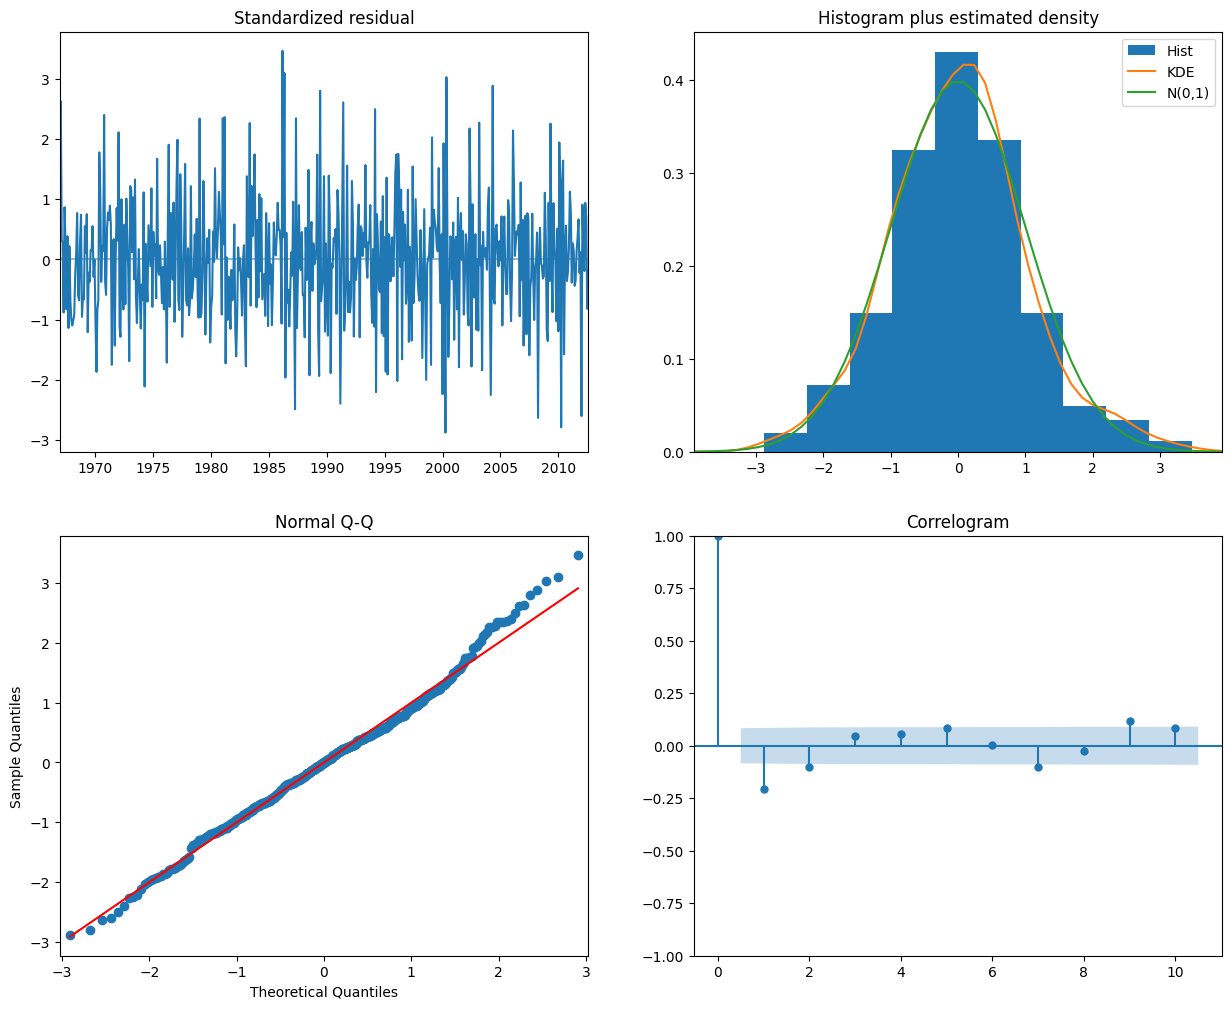

In [27]:
# Plotando o diagnóstico, para avaliação de resíduos e validação do modelo

ar_mod_f2.plot_diagnostics(figsize=(15,12))

plt.show()

### Modelo Autorregressivo de Médias Móveis (ARMA)

O modelo ARMA é uma ferramenta estatística avançada usada na análise de séries temporais que combina duas características principais: autoregressiva (AR) e média móvel (MA).

O modelo ARMA é expresso pela seguinte equação:

$X_t = c + \epsilon_t + \sum_{i=1}^p \beta_i X_{t-i} + \sum_{j=1}^q \theta_j \epsilon_{t-j}$

In [28]:
from statsmodels.tsa.arima.model import ARIMA

arma_mod = ARIMA(treino, order = (10, 0, 1)).fit()    # (p,d,q)

arma_mod.summary()

c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   TEMP   No. Observations:                  559
Model:                ARIMA(10, 0, 1)   Log Likelihood                -988.509
Date:                Sun, 20 Jul 2025   AIC                           2003.018
Time:                        11:54:51   BIC                           2059.257
Sample:                    02-01-1966   HQIC                          2024.979
                         - 08-01-2012                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.9727      0.008   2365.649      0.000      19.956      19.989
ar.L1         -0.0891      0.058     -1.544      0.123      -0.202       0.024
ar.L2         -0.3212      0.034     -9.505      0.000      -0.387      -0.255
ar.L3         -0.5019      0.032    -15.634      0.000      -0.565      -0.439
ar.L4         -0.4415      0.039    -11.432      0.000      -0.517      -0.366
ar.L5         -0.3242      0.046     -7.043      0.000      -0.414      -0.234
ar.L6         -0.3904      0.044     -8.842      0.000      -0.477      -0.304
ar.L7         -0.4096      0.039    -10.433      0.000      -0.487      -0.333
ar.L8         -0.3475      0.037     -9.299      0.000      -0.421      -0.274
ar.L9         -0.5193      0.038    -13.494      0.000      -0.595      -0.444
ar.L10        -0.3880      0.051     -7.630      0.000      -0.488      -0.288
ma.L1         -0.4049      0.057     -7.108      0.000      -0.516      -0.293
sigma2         1.9306      0.103     18.718      0.000       1.728       2.133
===================================================================================
Ljung-Box (L1) (Q):                   1.00   Jarque-Bera (JB):                15.07
Prob(Q):                              0.32   Prob(JB):                         0.00
Heteroskedasticity (H):               1.02   Skew:                             0.28
Prob(H) (two-sided):                  0.89   Kurtosis:                         3.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

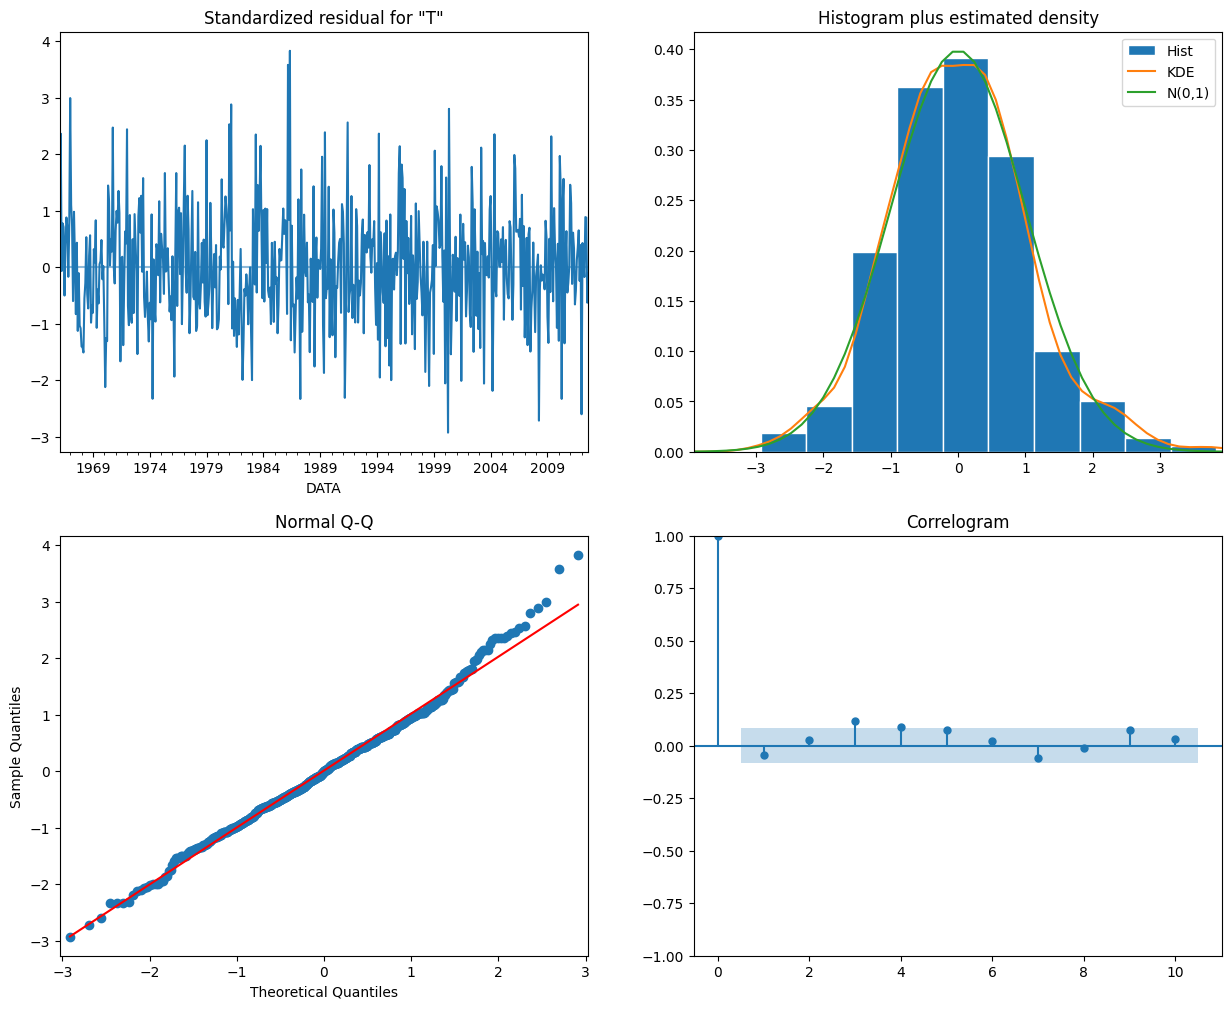

In [29]:
arma_mod.plot_diagnostics(figsize=(15, 12))

plt.show()

A análise dos resíduos pode ser ainda mais refinada com o auxílio de testes estatísticos, como o teste Ljung-Box. Este teste é usado para verificar a autocorrelação total em um conjunto de resíduos de um modelo ajustado. A principal função do teste Ljung-Box é determinar se os resíduos de um modelo autorregressivo são independentes, ou seja, se não possuem autocorrelações significativas em diversos lags.

O teste pode ser aplicado da seguinte forma:

In [30]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(arma_mod.resid, return_df=True)

print(lb_test)

      lb_stat  lb_pvalue
1    0.184573   0.667473
2    0.956038   0.620010
3   11.107251   0.011160
4   15.514967   0.003744
5   18.702625   0.002183
6   19.303560   0.003681
7   20.086983   0.005385
8   20.087250   0.010011
9   23.605113   0.004971
10  24.831257   0.005675


A função retorna um DataFrame com os resultados do teste para vários lags, mostrando para cada um deles se as autocorrelações são significativas. P-valores baixos (menores que 0,05) indicam que os resíduos possuem autocorrelação significativa, sugerindo que o modelo pode precisar de ajustes.

### Busca de parâmetros

In [31]:
 # Para o modelo arima, podemos usar uma função pré-definida para buscar os melhores parâmetros, da mesma forma que fizemos com o modelo AR, mas aqui precisamos fazê-la de forma mais manual


# Importando itertools
import itertools



# Creando nossa função
def grid_arima(p_inicial, p_final, q_inicial, q_final, d_valores, treino):
  # Definindo os parâmetros
  p_params = range(p_inicial, p_final)
  q_params = range(q_inicial, q_final)
  d_params = [d_valores]


  # Gerando todas as combinações possíveis usando product
  combinacoes = list(itertools.product(p_params, d_params, q_params)) 

  aic_grid = dict()


  # Treinando o modelo e salvando todas combinações
  for order in combinacoes:
    try:
      model = ARIMA(treino, order = order).fit()
      aic_grid[order] = list()
      aic_grid[order].append((model.aic if model.aic else float('inf')))
    except:
      continue
  return aic_grid, min(aic_grid, key=lambda x: aic_grid[x][0])

In [32]:
aic_arma = grid_arima(10,25,1,3,0,treino)    

# d_valores = 0 (modelo estacionário)

c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check m

In [33]:
aic_arma[1] # menores ordens para nosso modelo (p,d,q)

(24, 0, 2)

In [34]:
arma_mod_ot = ARIMA(treino, order=aic_arma[1]).fit()

arma_mod_ot.summary()

c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   TEMP   No. Observations:                  559
Model:                ARIMA(24, 0, 2)   Log Likelihood                -934.111
Date:                Sun, 20 Jul 2025   AIC                           1924.222
Time:                        11:56:33   BIC                           2045.355
Sample:                    02-01-1966   HQIC                          1971.525
                         - 08-01-2012                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.9729      0.004   4630.319      0.000      19.964      19.981
ar.L1         -0.4115      0.318     -1.296      0.195      -1.034       0.211
ar.L2          0.1878      0.130      1.444      0.149      -0.067       0.443
ar.L3         -0.1356      0.090     -1.511      0.131      -0.311       0.040
ar.L4         -0.1600      0.095     -1.685      0.092      -0.346       0.026
ar.L5         -0.0139      0.092     -0.150      0.880      -0.195       0.167
ar.L6         -0.0525      0.092     -0.569      0.569      -0.233       0.128
ar.L7         -0.1845      0.090     -2.055      0.040      -0.361      -0.008
ar.L8         -0.0813      0.093     -0.873      0.383      -0.264       0.101
ar.L9         -0.0986      0.080     -1.229      0.219      -0.256       0.059
ar.L10        -0.0773      0.084     -0.916      0.360      -0.243       0.088
ar.L11         0.0554      0.075      0.741      0.459      -0.091       0.202
ar.L12         0.3244      0.068      4.779      0.000       0.191       0.457
ar.L13         0.1144      0.106      1.080      0.280      -0.093       0.322
ar.L14        -0.1149      0.060     -1.902      0.057      -0.233       0.004
ar.L15        -0.1032      0.056     -1.829      0.067      -0.214       0.007
ar.L16        -0.1563      0.066     -2.354      0.019      -0.286      -0.026
ar.L17        -0.1486      0.073     -2.033      0.042      -0.292      -0.005
ar.L18        -0.0841      0.069     -1.220      0.222      -0.219       0.051
ar.L19        -0.0309      0.066     -0.469      0.639      -0.160       0.098
ar.L20        -0.0784      0.064     -1.228      0.219      -0.204       0.047
ar.L21        -0.1890      0.067     -2.829      0.005      -0.320      -0.058
ar.L22        -0.1823      0.084     -2.176      0.030      -0.347      -0.018
ar.L23         0.0982      0.080      1.221      0.222      -0.059       0.256
ar.L24         0.1763      0.064      2.775      0.006       0.052       0.301
ma.L1         -0.2012      0.316     -0.636      0.525      -0.821       0.419
ma.L2         -0.6379      0.271     -2.350      0.019      -1.170      -0.106
sigma2         1.5870      0.090     17.611      0.000       1.410       1.764
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                18.39
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               0.96   Skew:                             0.29
Prob(H) (two-sided):                  0.78   Kurtosis:                         3.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

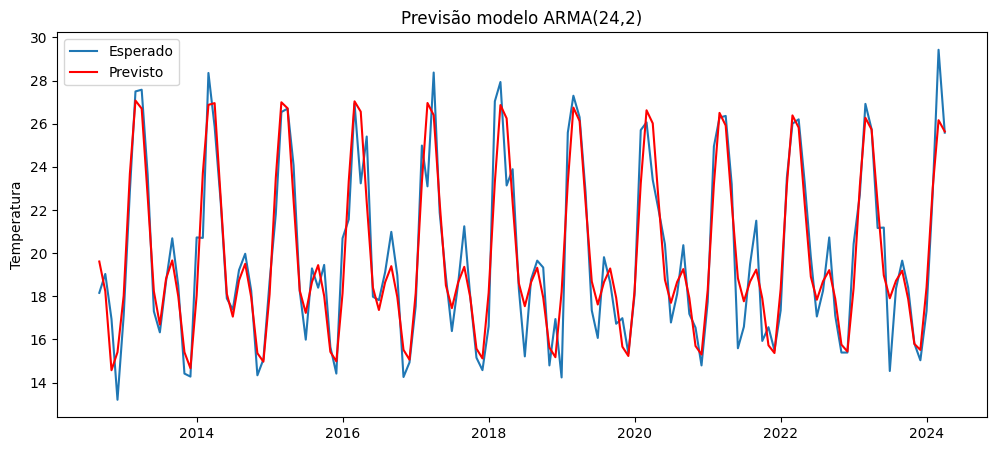


Métricas:

MAE: 1.0654759243285838
MSE: 1.9803190570461036


In [35]:
plot_prev(treino, teste, arma_mod_ot, 'ARMA(24,2)')

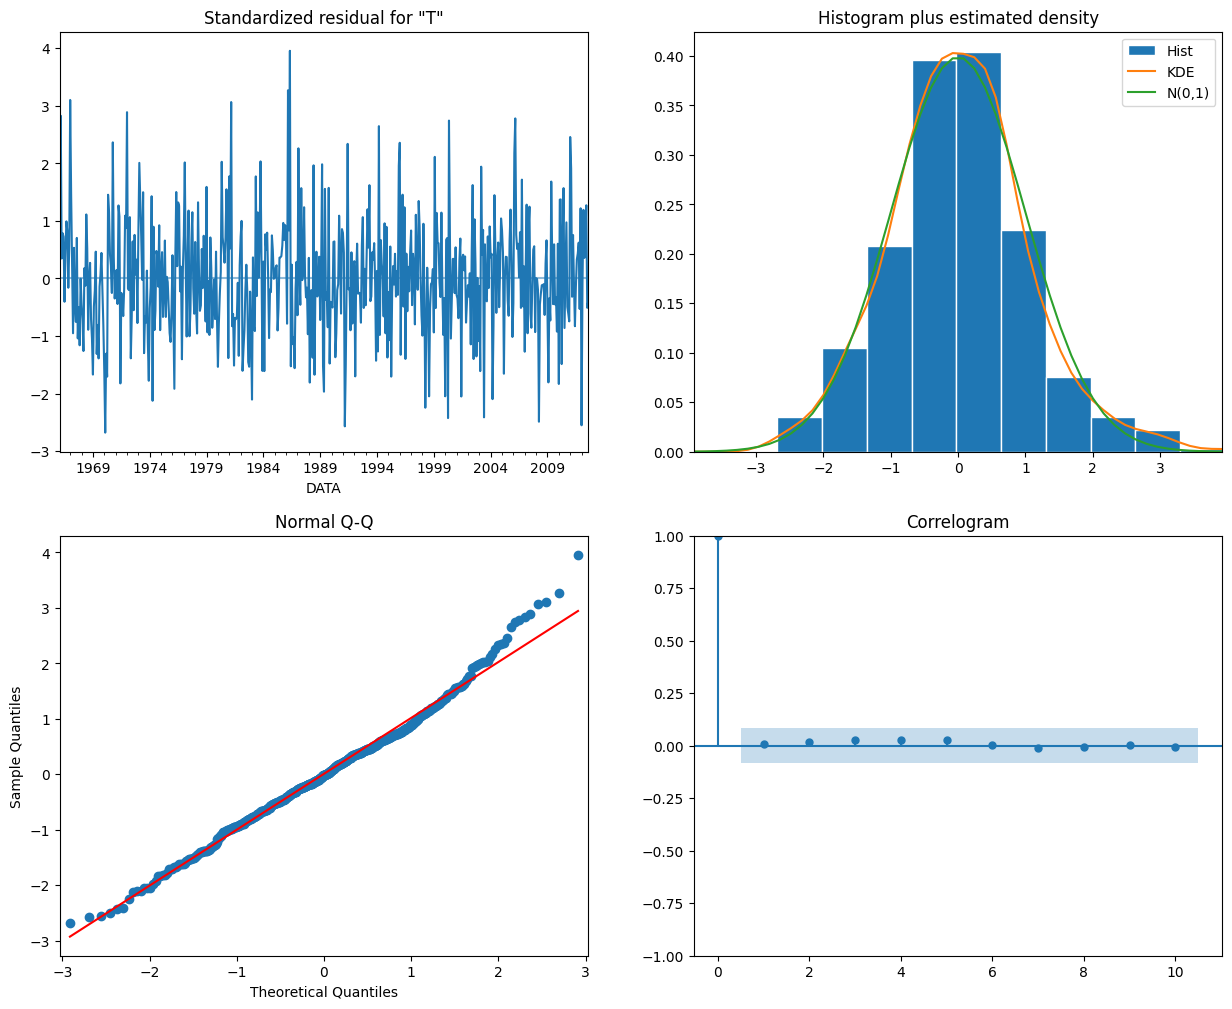

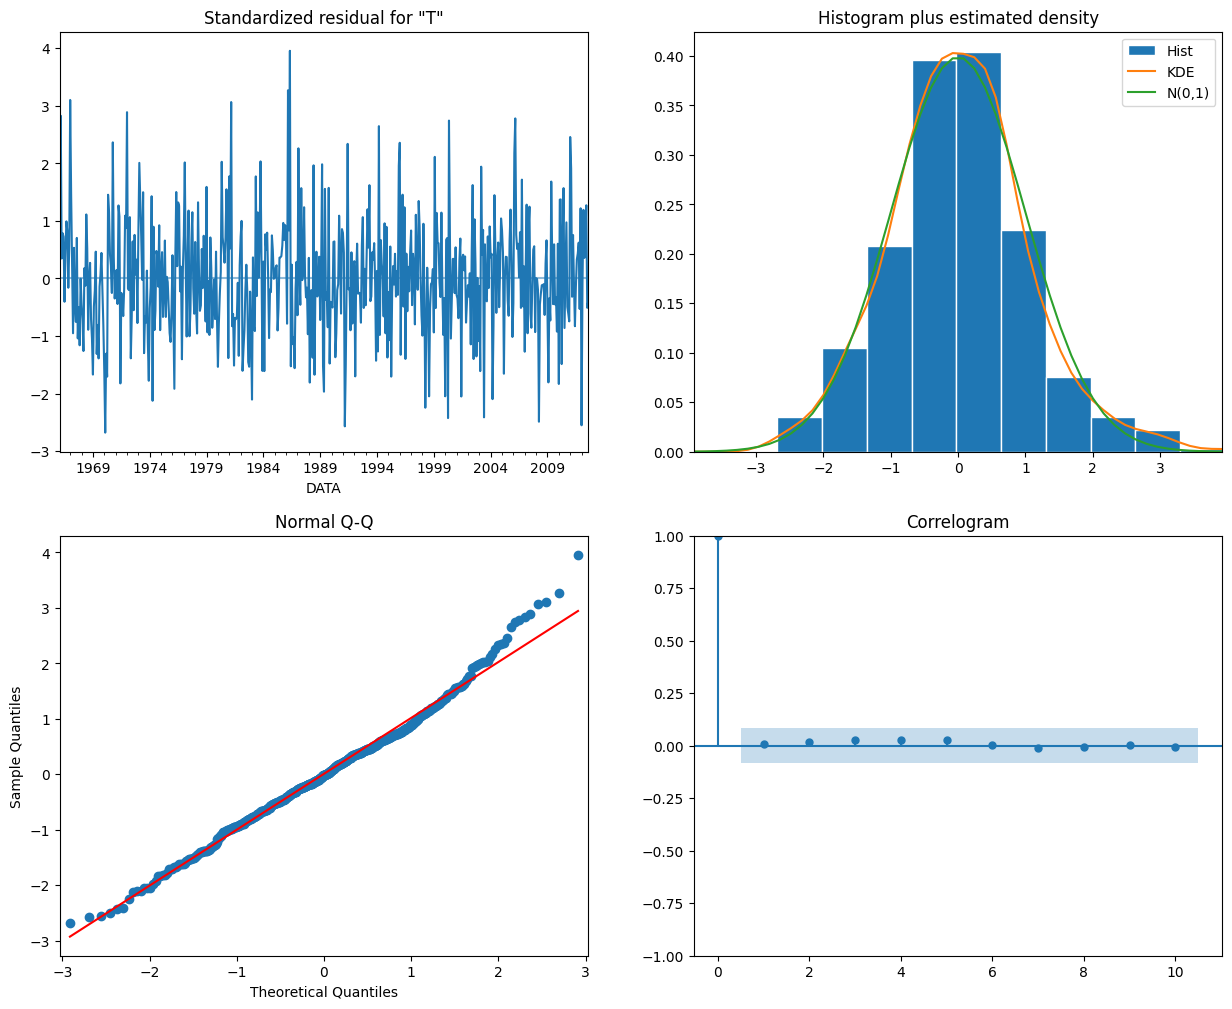

In [36]:
arma_mod_ot.plot_diagnostics(figsize=(15,12))

# Fazenda 3

![Alt text: Imagem de uma fazenda com plantações de arroz](https://github.com/Mirlaa/s-ries-temporais-statsmodels/blob/main/imagens/Fazenda%203.png?raw=true)

In [37]:
# Apresentando os dados da Fazenda 3

df_f3 = pd.read_csv(dados_f3)

df_f3

,DATA,TEMP
0,1965-09-01,33.30
1,1965-10-01,32.88
2,1965-11-01,30.28
3,1965-12-01,30.42
4,1966-01-01,30.39
...,...,...
699,2023-12-01,31.72
700,2024-01-01,32.22
701,2024-02-01,32.29
702,2024-03-01,29.60


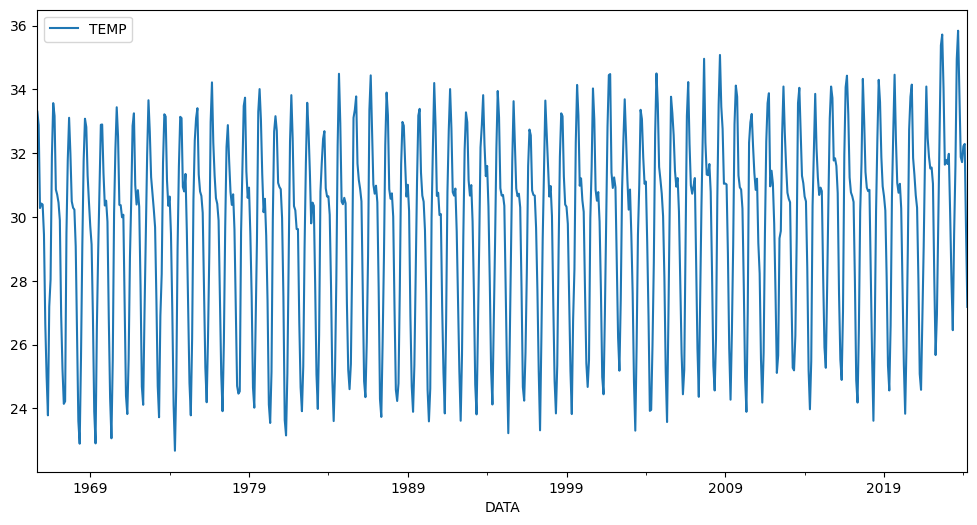

In [38]:
# Transformando a coluna DATA em datetime e transformando-a em index

df_f3['DATA'] = pd.to_datetime(df_f3['DATA'], format='%Y-%m-%d')

df_f3.set_index(['DATA'], inplace=True, drop=True)

fig = df_f3.plot(figsize=(12, 6))

In [39]:
# Testando estacionariedade

estac(df_f3)

Valor-p do Teste ADF: 0.0669
Não rejeitar a Hipótesqe Nula: a série não é estacionária

Valor-p do Teste KPSS: 0.0100
Rejeitar a Hipótese Nula: a série não é estacionária



C:\Users\mau_a\AppData\Local\Temp\ipykernel_4428\1290556167.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_saida = kpss(df)


In [40]:
# Realizando a diferença para tentar torná-la estacionária

df_f3.diff(1)

,TEMP
DATA,
1965-09-01,NaN
1965-10-01,-0.42
1965-11-01,-2.60
1965-12-01,0.14
1966-01-01,-0.03
...,...
2023-12-01,-0.16
2024-01-01,0.50
2024-02-01,0.07


In [41]:
# Testando novamente a séria após a diferença, para verificar estacionariedade

estac(df_f3.diff(1).iloc[1:])   # Usamos iloc 1 porque o primeiro valor é nan

Valor-p do Teste ADF: 0.0000
Rejeitar a Hipótese Nula: a série é estacionária

Valor-p do Teste KPSS: 0.1000
Não rejeitar a Hipótesqe Nula: a série é estacionária



C:\Users\mau_a\AppData\Local\Temp\ipykernel_4428\1290556167.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_saida = kpss(df)


## Modelo Integrado Autorregressivo de Média Móveis (ARIMA)

In [42]:
# Dividindo os dados em treino e teste e garantindo a presença de todas as datas nos datasets

divisao = int(len(df_f3) * 0.8)

treino = df_f3.iloc[:divisao].asfreq('MS')

teste = df_f3.iloc[divisao:].asfreq('MS')

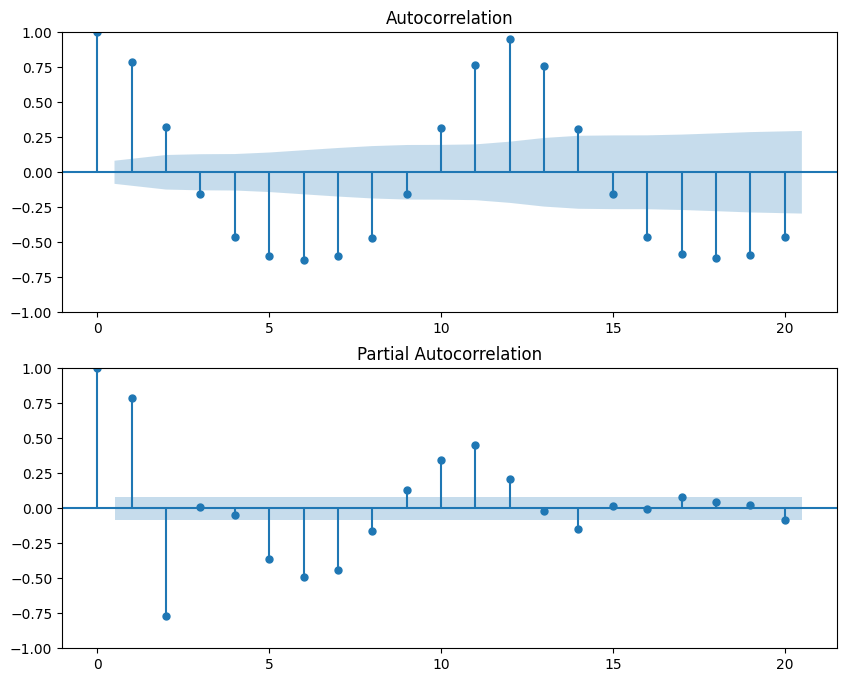

In [43]:
# Plotando gráficos de acf e pacf

fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(211)
fig = plot_acf(treino, lags=20, ax=ax1)
ax2 = fig.add_subplot(212)
fig = plot_pacf(treino, lags=20, ax=ax2)

O modelo ARIMA combina três componentes principais: autorregressivo (AR), diferenciado (I de Integrated, ou integrado) e de média móvel (MA), o que o torna capaz de modelar uma ampla variedade de dados temporais.

O modelo ARIMA é geralmente representado como ARIMA(p, d, q), onde:

- $(p)$ é o número de termos autoregressivos,
- $( d )$ é o número de diferenciações necessárias para tornar a série temporal estacionária,
- $( q )$ é o número de termos de média móvel.

A equação genérica do modelo ARIMA é:

$(1 - \sum_{i=1}^p \beta_i L^i)(1 - L)^d X_t = (1 + \sum_{j=1}^q \theta_j L^j) \epsilon_t$

In [44]:
# Pela análise inicial, o gráfico de pacf retorna a área de confiança após o lag=14, e seu retorno ocorre 2 vezes, assim usaremos de início p=14 e q=2

arima_mod = ARIMA(treino, order = (14, 1, 2)).fit()

arima_mod.summary()

c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   TEMP   No. Observations:                  563
Model:                ARIMA(14, 1, 2)   Log Likelihood                -544.664
Date:                Sun, 20 Jul 2025   AIC                           1123.329
Time:                        11:56:36   BIC                           1196.964
Sample:                    09-01-1965   HQIC                          1152.077
                         - 07-01-2012                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4253      0.346     -1.229      0.219      -1.104       0.253
ar.L2          0.1354      0.362      0.374      0.708      -0.574       0.845
ar.L3         -0.2587      0.294     -0.879      0.380      -0.836       0.318
ar.L4         -0.1695      0.325     -0.521      0.602      -0.807       0.468
ar.L5         -0.0781      0.342     -0.229      0.819      -0.748       0.591
ar.L6         -0.0217      0.336     -0.064      0.949      -0.681       0.638
ar.L7         -0.1163      0.311     -0.373      0.709      -0.727       0.494
ar.L8         -0.1523      0.317     -0.481      0.631      -0.773       0.469
ar.L9         -0.1408      0.330     -0.426      0.670      -0.788       0.506
ar.L10        -0.1128      0.338     -0.333      0.739      -0.776       0.550
ar.L11         0.2168      0.339      0.640      0.522      -0.448       0.881
ar.L12         0.4746      0.253      1.875      0.061      -0.022       0.971
ar.L13         0.3617      0.102      3.529      0.000       0.161       0.563
ar.L14         0.0380      0.064      0.592      0.554      -0.088       0.164
ma.L1         -0.0963      0.340     -0.283      0.777      -0.763       0.570
ma.L2         -0.7254      0.248     -2.928      0.003      -1.211      -0.240
sigma2         0.3999      0.023     17.219      0.000       0.354       0.445
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                17.54
Prob(Q):                              0.87   Prob(JB):                         0.00
Heteroskedasticity (H):               1.23   Skew:                             0.21
Prob(H) (two-sided):                  0.15   Kurtosis:                         3.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

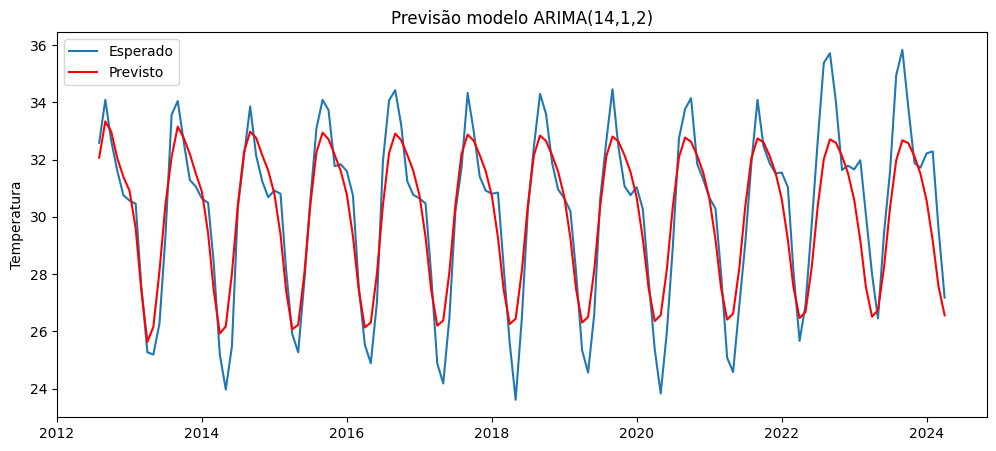


Métricas:

MAE: 1.0016324438508015
MSE: 1.590116909092425


In [45]:
plot_prev(treino, teste, arima_mod, 'ARIMA(14,1,2)')

### Busca de parâmetros

In [46]:
# Usamos nossa função criada para testar os melhores parâmetros para o modelo ARIMA

aic_arima = grid_arima(14,25,1,3,1,treino)

c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check m

In [47]:
aic_arima[1]  # usamos [1] para checar os melhores parâmetros

(24, 1, 2)

In [48]:
# Treinando modelo e plotando sumário

arima_mod_ot = ARIMA(treino, order = (24, 1, 2)).fit()

print(arima_mod_ot.summary())

c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:                   TEMP   No. Observations:                  563
Model:                ARIMA(24, 1, 2)   Log Likelihood                -504.903
Date:                Sun, 20 Jul 2025   AIC                           1063.805
Time:                        11:57:31   BIC                           1180.756
Sample:                    09-01-1965   HQIC                          1109.464
                         - 07-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4460      0.151     -2.961      0.003      -0.741      -0.151
ar.L2          0.1553      0.085      1.832      0.067      -0.011       0.321
ar.L3         -0.1432      0.071     -2.030      0.0

c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


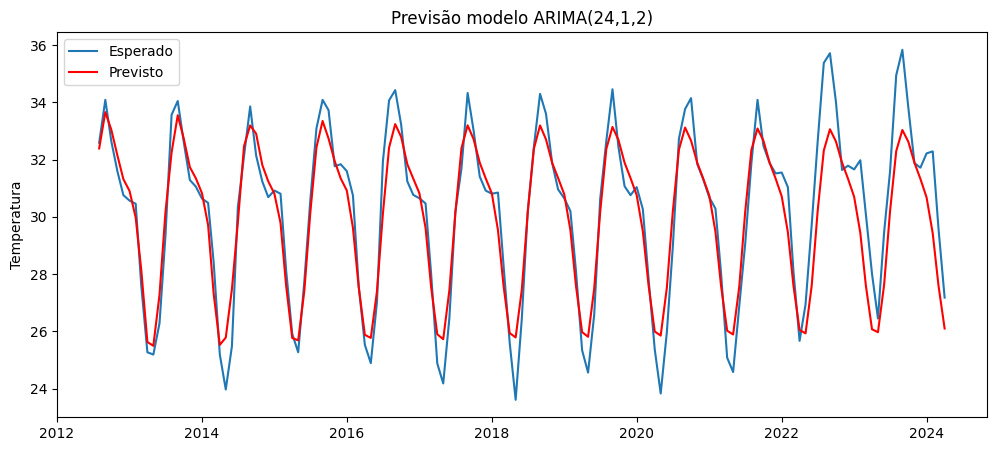


Métricas:

MAE: 0.8330080907591607
MSE: 1.1629090904079769


In [49]:
plot_prev(treino, teste, arima_mod_ot, 'ARIMA(24,1,2)')

https://cursos.alura.com.br/course/regressao-realizando-previsao-series-temporais-statsmodels/task/165240

### **A sazonalidade**

<Axes: title={'center': 'Sazonalidade df_f3'}, xlabel='DATA'>

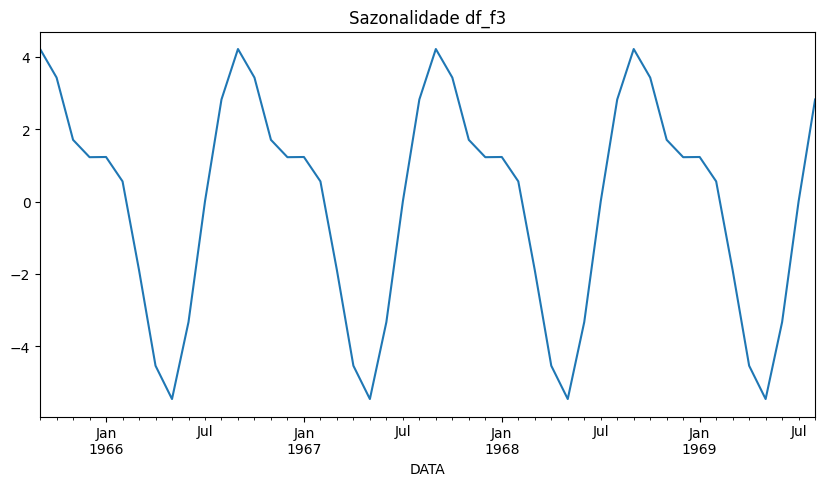

In [50]:
# Usando a função seasonal_deocmpose para a fazenda 3, percemos a presença de característica sazonal de 12 meses

from statsmodels.tsa.seasonal import seasonal_decompose

decomposicao_df = seasonal_decompose(df_f3)

fig = plt.figure(figsize=(10,5))

decomposicao_df.seasonal.iloc[:48].plot(title='Sazonalidade df_f3')

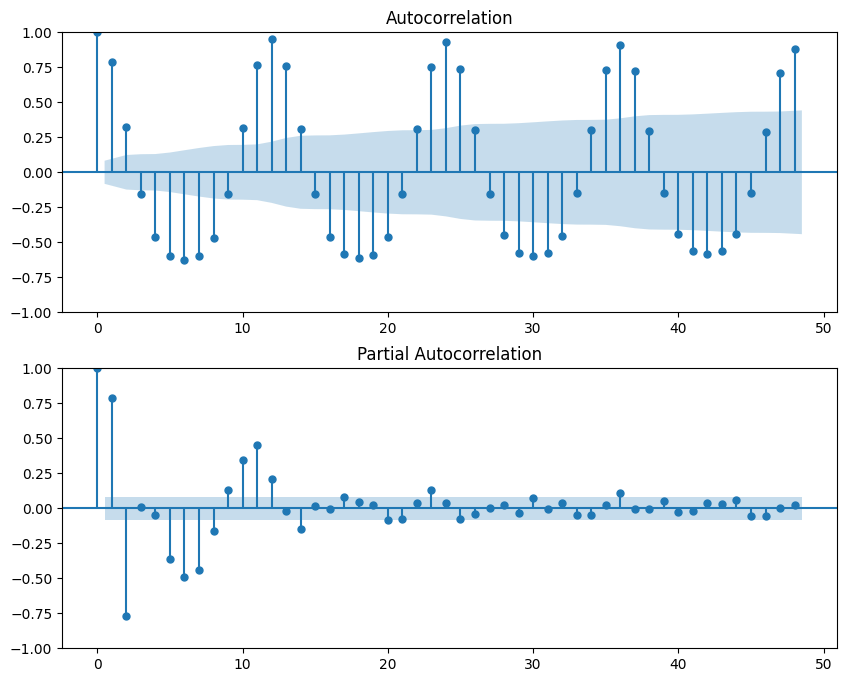

In [51]:
# Plotando gráficos acf e pacf

fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_subplot(211)
fig = plot_acf(treino, lags=48, ax=ax1)
ax2 = fig.add_subplot(212)
fig = plot_pacf(treino, lags=48, ax=ax2)

## Modelo Autorregressivo Sazonal de Média Móveis Integrado (SARIMA)

O modelo SARIMA é uma extensão do modelo ARIMA, projetado especificamente para modelar e prever séries temporais que exibem sazonalidade.

O modelo SARIMA pode ser descrito pela seguinte equação, que combina tanto os efeitos sazonais quanto os não sazonais:

$(1 - \sum_{i=1}^p \beta_i L^i)(1 - \sum_{i=1}^P B_i L^{is})(1 - L)^d(1 - L^s)^D X_t = (1 + \sum_{j=1}^q \theta_j L^j)(1 + \sum_{j=1}^Q \Theta_j L^{js}) \epsilon_t$

In [52]:
# Importando modelo SARIMAX

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [53]:
sarima_mod = SARIMAX(treino, order=(11,1,2), seasonal_order=(2,1,1,12)).fit()  

sarima_mod.summary()


# P = 2: A partir do gráfico de PACF sazonal, observamos dois lags significativos fora da faixa de confiança.
# D = 1: Foi aplicada uma diferenciação sazonal para tornar a série estacionária em relação à sazonalidade.
# Q = 1: A ACF sazonal mostra um pico no primeiro lag sazonal, justificando Q = 1.
# s = 12: A sazonalidade anual foi identificada, com ciclos completos a cada 12 meses.


c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                       
=============================================================================================
Dep. Variable:                                  TEMP   No. Observations:                  563
Model:             SARIMAX(11, 1, 2)x(2, 1, [1], 12)   Log Likelihood                -456.394
Date:                               Sun, 20 Jul 2025   AIC                            946.787
Time:                                       11:57:42   BIC                           1020.056
Sample:                                   09-01-1965   HQIC                           975.419
                                        - 07-01-2012                                         
Covariance Type:                                 opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5652      0.148     -3.831      0.000      -0.854      -0.276
ar.L2          0.2371      0.065      3.668      0.000       0.110       0.364
ar.L3          0.0324      0.056      0.575      0.565      -0.078       0.143
ar.L4          0.0575      0.055      1.038      0.299      -0.051       0.166
ar.L5          0.0756      0.065      1.170      0.242      -0.051       0.202
ar.L6          0.0573      0.064      0.889      0.374      -0.069       0.184
ar.L7         -0.0024      0.061     -0.039      0.969      -0.123       0.118
ar.L8          0.0428      0.056      0.764      0.445      -0.067       0.153
ar.L9          0.1099      0.058      1.905      0.057      -0.003       0.223
ar.L10         0.0692      0.062      1.123      0.261      -0.052       0.190
ar.L11         0.0791      0.047      1.665      0.096      -0.014       0.172
ma.L1         -0.1519      0.144     -1.055      0.291      -0.434       0.130
ma.L2         -0.8377      0.141     -5.953      0.000      -1.114      -0.562
ar.S.L12       0.0006      0.054      0.011      0.991      -0.106       0.107
ar.S.L24      -0.0210      0.047     -0.451      0.652      -0.113       0.070
ma.S.L12      -0.9972      0.395     -2.527      0.012      -1.771      -0.224
sigma2         0.2792      0.105      2.650      0.008       0.073       0.486
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                87.87
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               1.34   Skew:                             0.17
Prob(H) (two-sided):                  0.05   Kurtosis:                         4.93
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

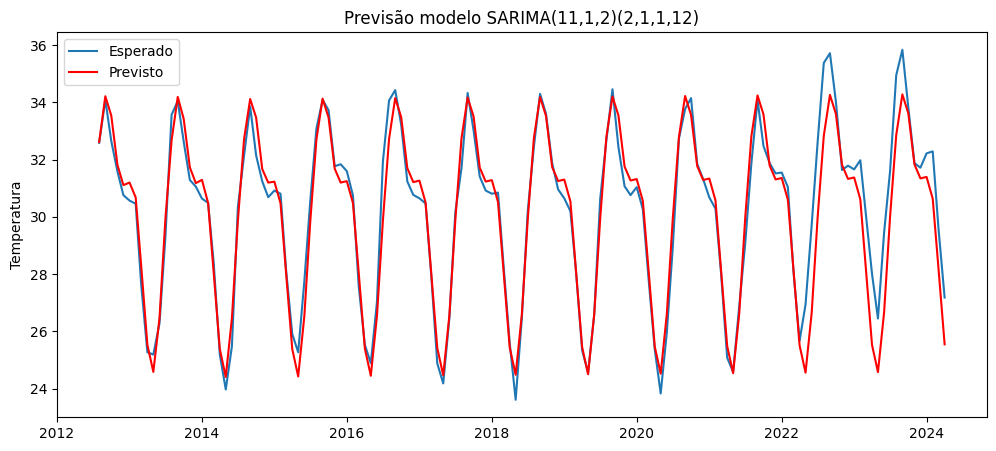


Métricas:

MAE: 0.5943441565436243
MSE: 0.7496244721334846


In [54]:
plot_prev(treino,teste,sarima_mod,'SARIMA(11,1,2)(2,1,1,12)')

# Previsões das Fazendas

Temos 3 modelos para 3 conjuntos de dados sobre as temperaturas das fazendas

* Fazenda 1 modelo $AR(34)$
* Fazenda 2 modelo $ARMA(24,2)$
* Fazenda 3 modelo $SARIMA(11, 1, 1)\times (2, 1, 1, 12)$

```Python
mod_f1 = AutoReg(df_f1, 34, old_names=False).fit()
mod_f2 = ARIMA(df_f2, order=(24,0,2)).fit()
mod_f3 = SARIMAX(df_f3, order=(11, 1, 1), seasonal_order=(2, 1, 1, 12)).fit()
```

In [ ]:
mod_f1 = AutoReg(df_f1, 34, old_names=False).fit()
mod_f2 = ARIMA(df_f2, order=(24,0,2)).fit()
mod_f3 = SARIMAX(df_f3, order=(11, 1, 1), seasonal_order=(2, 1, 1, 12)).fit()

c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\L

In [ ]:
previsao_f1 = mod_f1.predict(len(df_f1), len(df_f1)+35, dynamic=False)   # Dynamic= False, não considera previsões para gerar dados posteriores de previsões,mas apenas os dados reais
previsao_f2 = mod_f1.predict(len(df_f2), len(df_f2)+35, dynamic=False)
previsao_f3 = mod_f3.predict(len(df_f3), len(df_f3)+35, dynamic=False)

c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
c:\Users\mau_a\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [ ]:
previsao_f1

2024-05-01    23.754813
2024-06-01    25.073979
2024-07-01    25.745189
2024-08-01    25.482945
2024-09-01    24.688088
2024-10-01    23.396004
2024-11-01    21.987786
2024-12-01    20.884098
2025-01-01    20.462515
2025-02-01    20.671650
2025-03-01    21.437362
2025-04-01    22.747177
2025-05-01    24.272593
2025-06-01    25.631728
2025-07-01    26.151243
2025-08-01    25.772192
2025-09-01    24.810964
2025-10-01    23.402365
2025-11-01    21.817364
2025-12-01    20.637679
2026-01-01    20.235018
2026-02-01    20.583082
2026-03-01    21.474468
2026-04-01    22.864869
2026-05-01    24.469955
2026-06-01    25.757861
2026-07-01    26.256951
2026-08-01    25.993914
2026-09-01    25.070860
2026-10-01    23.642252
2026-11-01    22.077607
2026-12-01    20.899951
2027-01-01    20.356688
2027-02-01    20.564789
2027-03-01    21.397561
2027-04-01    22.680671
Freq: MS, dtype: float64